In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

In [ ]:
train_images = train_X / 255.0
test_images = test_X / 255.0

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28 ,28, 1)),
    keras.layers.MaxPool2D(2, 2),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)
])

Compile the model

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.fit(train_X, train_Y, epochs=5, validation_data=(test_X, test_Y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 32ms/step - accuracy: 0.7711 - loss: 1.5518 - val_accuracy: 0.8554 - val_loss: 0.4143
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.8748 - loss: 0.3461 - val_accuracy: 0.8742 - val_loss: 0.3517
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.8917 - loss: 0.2948 - val_accuracy: 0.8851 - val_loss: 0.3212
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.8991 - loss: 0.2708 - val_accuracy: 0.8851 - val_loss: 0.3275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9090 - loss: 0.2451 - val_accuracy: 0.8838 - val_loss: 0.3255


In [ ]:
model.fit(train_X, train_Y, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9151 - loss: 0.2271
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9221 - loss: 0.2071
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9278 - loss: 0.1929
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9301 - loss: 0.1853
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9356 - loss: 0.1678
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 32ms/step - accuracy: 0.9405 - loss: 0.1572
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9455 - loss: 0.1483
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9490 - loss: 0.1359
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9514 - loss: 0.1296
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9495 - loss: 0.1394


In [ ]:
test_loss, test_acc = model.evaluate(test_X,  test_Y)

print('\nTest accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8945 - loss: 0.4745

Test accuracy: 0.8952999711036682


In [ ]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

In [ ]:
predictions = probability_model.predict(test_X)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [ ]:
predictions[0]

array([3.5871660e-38, 0.0000000e+00, 3.4734439e-32, 3.2298418e-35,
       0.0000000e+00, 4.6608138e-19, 3.5066360e-31, 7.5125163e-16,
       2.6344022e-34, 9.9999994e-01], dtype=float32)

In [ ]:
np.argmax(predictions[0])

9

In [ ]:
test_Y[0]

9

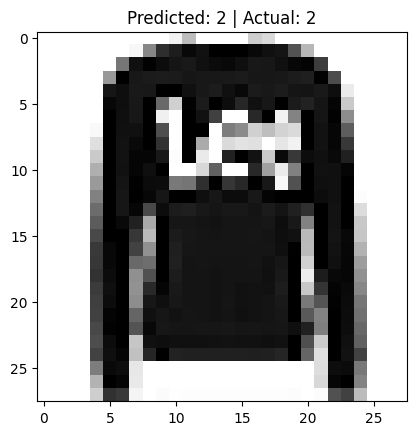

In [ ]:
def show_prediction(index):
    plt.imshow(test_images[index].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Predicted: {np.argmax(predictions[index])} | Actual: {test_Y[index]}")
    plt.show()
show_prediction(1)